# Inverse beamforming: recovering channel data with `zea.inverse`

Delay-and-sum (DAS) beamforming maps **pre-beamformed channel data** to a **post-beamformed
image**. This notebook runs that map *backwards*: given only a beamformed image, we recover the
channel data that produced it, using the [`zea.inverse`](../../_autosummary/zea.inverse.rst)
subpackage.

Because the DAS operator sums on the order of `n_el * n_tx` samples into every pixel, this
inversion is severely underdetermined. We compare the two provided strategies:

1. **Direct (pseudo-inverse)** — solve for the full channel-data cube with CGLS. This
   reproduces the image essentially perfectly, yet recovers the *physical* channel data poorly:
   CGLS from zero converges to the minimum-norm solution, which is generally not the true data.
2. **Scatterer prior** — parameterize the medium as point scatterers (positions seeded from the
   image, magnitudes solved by CGLS). The physical parameterization regularizes the nullspace
   and recovers channel data far better on point-target scans.

The scatterer-prior inversion follows the off-grid scatterer model of
[van de Schaft et al., *Off-Grid Ultrasound Imaging by Stochastic Optimization*](https://arxiv.org/abs/2407.02285).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/pipeline/inverse_beamforming_example.ipynb)
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/pipeline/inverse_beamforming_example.ipynb)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import matplotlib.pyplot as plt
import numpy as np
from keras import ops
from scipy.signal import hilbert

import zea
from zea import Parameters
from zea.beamform.delays import compute_t0_delays_planewave
from zea.beamform.phantoms import fish
from zea.inverse import DASOperator, ScattererSimulator, invert_direct, invert_scatterers

zea.init_device()

zea: Using backend 'jax'


zea: WARNING nvidia-smi is not available. Please install nvidia-utils. Cannot retrieve GPU memory. Falling back to CPU.


'cpu'

## A synthetic point-scatterer scan

We build a small plane-wave acquisition entirely from
[`zea.Parameters`](../../parameters_doc.rst): a 64-element linear array firing 3 steered plane
waves, with a windowed-sine two-way waveform. The ground-truth medium is the `fish` point
phantom from [`zea.beamform.phantoms`](../../_autosummary/zea.beamform.phantoms.rst) — since we
simulate the channel data ourselves, we know exactly what the inversion should recover.

In [3]:
n_el, n_tx, n_ax = 64, 3, 448
center_frequency, sampling_frequency, sound_speed = 3.125e6, 12.5e6, 1540.0
wavelength = sound_speed / center_frequency

element_x = np.linspace(-11e-3, 11e-3, n_el)
probe_geometry = np.stack([element_x, np.zeros(n_el), np.zeros(n_el)], axis=-1).astype("float32")
polar_angles = np.array([-0.15, 0.0, 0.15], dtype="float32")

# Two-way waveform: a 2-cycle windowed sine sampled at 250 MHz
waveform_sampling_frequency = 250e6
t = np.arange(int(2 / center_frequency * waveform_sampling_frequency)) / waveform_sampling_frequency
pulse = (np.sin(2 * np.pi * center_frequency * t) * np.hanning(t.size)).astype("float32")

parameters = Parameters(
    probe_geometry=probe_geometry,
    t0_delays=compute_t0_delays_planewave(probe_geometry, polar_angles, sound_speed=sound_speed),
    tx_apodizations=np.ones((n_tx, n_el), dtype="float32"),
    initial_times=np.full(n_tx, 8e-6, dtype="float32"),
    sampling_frequency=sampling_frequency,
    center_frequency=center_frequency,
    sound_speed=sound_speed,
    n_ax=n_ax,
    n_el=n_el,
    n_tx=n_tx,
    n_ch=1,
    n_frames=1,
    focus_distances=np.full(n_tx, np.inf, dtype="float32"),
    polar_angles=polar_angles,
    azimuth_angles=np.zeros(n_tx, dtype="float32"),
    transmit_origins=np.zeros((n_tx, 3), dtype="float32"),
    waveforms_two_way=np.tile(pulse, (n_tx, 1)),
    element_width=float(element_x[1] - element_x[0]) * 0.9,
    xlims=(-11e-3, 11e-3),
    zlims=(8e-3, 23e-3),
    pixels_per_wavelength=2,
    f_number=1.0,
)

# Ground-truth scatterers: the fish phantom, scaled to fit our field of view
scatterer_positions = (fish() * 0.7).astype("float32")
scatterer_magnitudes = np.ones(len(scatterer_positions), dtype="float32")

simulator = ScattererSimulator(parameters, chunk_size=2048)
channel_data_true = simulator(scatterer_magnitudes, positions=scatterer_positions)
print("ground-truth channel data:", channel_data_true.shape, "(n_tx, n_ax, n_el)")

ground-truth channel data: (3, 448, 64) (n_tx, n_ax, n_el)


## The DAS beamformer as a linear operator

[`DASOperator`](../../_autosummary/zea.inverse.rst) wraps the standard `zea` beamforming
pipeline — [`TOFCorrection`](../../_autosummary/zea.ops.rst) followed by
[`DelayAndSum`](../../_autosummary/zea.ops.rst), chunked over grid pixels with
[`PatchedGrid`](../../_autosummary/zea.ops.rst) to bound memory — into a linear map
`channel data -> image`. Since it is built from differentiable Keras ops, its adjoint comes
for free via automatic differentiation — which is all we need for matrix-free least-squares
inversion. We beamform the ground-truth channel data to get the *measured image* that will
be the only input to the inversions below.

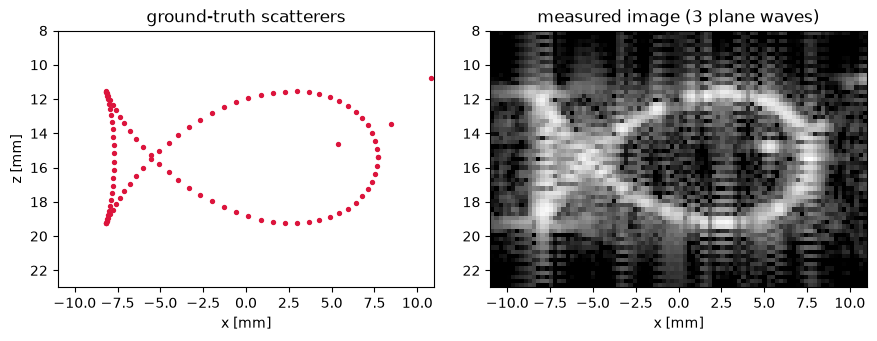

In [4]:
operator = DASOperator(parameters)
image_measured = operator.forward(channel_data_true)


def to_bmode(flat_image):
    """Envelope-detect (along depth) and log-compress a flat RF image for display."""
    rf = ops.convert_to_numpy(operator.to_grid(flat_image))
    envelope = np.abs(hilbert(rf, axis=0))
    return 20 * np.log10(envelope / envelope.max() + 1e-6)


extent = [-11, 11, 23, 8]  # mm
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(scatterer_positions[:, 0] * 1e3, scatterer_positions[:, 2] * 1e3, s=8, c="crimson")
axes[0].set(
    xlim=extent[:2],
    ylim=extent[2:],
    title="ground-truth scatterers",
    xlabel="x [mm]",
    ylabel="z [mm]",
)
axes[0].set_aspect("equal")
axes[1].imshow(
    to_bmode(image_measured), cmap="gray", vmin=-40, vmax=0, extent=extent, aspect="equal"
)
axes[1].set(title="measured image (3 plane waves)", xlabel="x [mm]")
plt.tight_layout()
plt.show()

## Direct inversion: the pseudo-inverse

[`invert_direct`](../../_autosummary/zea.inverse.rst) treats every sample of the channel-data
cube as a free variable and minimizes `||beamform(channel_data) - image||^2` with CGLS. Started
from zero, CGLS converges to the **minimum-norm** least-squares solution — the Moore–Penrose
pseudo-inverse applied to the image.

In [5]:
result_direct = invert_direct(operator, image_measured, n_iter=30, verbose=True)


def correlation(a, b):
    """Absolute normalized correlation between two arrays."""
    a = np.asarray(ops.convert_to_numpy(a)).ravel()
    b = np.asarray(ops.convert_to_numpy(b)).ravel()
    a, b = a - a.mean(), b - b.mean()
    return abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30)


print(
    "pre-BF (channel data) correlation: "
    f"{correlation(result_direct.channel_data, channel_data_true):.3f}"
)
print(f"post-BF (image) correlation:       {correlation(result_direct.image, image_measured):.3f}")

zea: cgls iteration   3 | relative residual 3.7656e-01


zea: cgls iteration   6 | relative residual 1.8759e-01


zea: cgls iteration   9 | relative residual 1.0662e-01


zea: cgls iteration  12 | relative residual 7.1352e-02


zea: cgls iteration  15 | relative residual 4.9477e-02


...

zea: cgls iteration  21 | relative residual 3.1345e-02


zea: cgls iteration  24 | relative residual 2.5449e-02


zea: cgls iteration  27 | relative residual 2.1485e-02


zea: cgls iteration  30 | relative residual 1.7093e-02


pre-BF (channel data) correlation: 0.516
post-BF (image) correlation:       1.000


The image fit is essentially perfect while the channel-data correlation is poor — the
minimum-norm solution concentrates energy where the beamformer *samples*, not where the physical
echoes are. This is the nullspace problem in action.

## Scatterer-prior inversion

[`invert_scatterers`](../../_autosummary/zea.inverse.rst) instead represents the medium as point
scatterers: positions are seeded from the image envelope
([`seed_scatterers`](../../_autosummary/zea.inverse.rst)), and their magnitudes are solved with
CGLS through the composition `beamform(simulate(positions, magnitudes))` — still a linear
problem, but now constrained to physically consistent echoes.

In [6]:
result_scat = invert_scatterers(
    operator,
    image_measured,
    n_scatterers=3000,
    n_iter=30,
    seed=0,
    verbose=True,
)
print(
    "pre-BF (channel data) correlation: "
    f"{correlation(result_scat.channel_data, channel_data_true):.3f}"
)
print(f"post-BF (image) correlation:       {correlation(result_scat.image, image_measured):.3f}")

zea: cgls iteration   3 | relative residual 3.5830e-01


zea: cgls iteration   6 | relative residual 2.2972e-01


zea: cgls iteration   9 | relative residual 1.7551e-01


zea: cgls iteration  12 | relative residual 1.4489e-01


zea: cgls iteration  15 | relative residual 1.2787e-01


...

zea: cgls iteration  21 | relative residual 1.0398e-01


zea: cgls iteration  24 | relative residual 9.6215e-02


zea: cgls iteration  27 | relative residual 9.1080e-02


zea: cgls iteration  30 | relative residual 8.5885e-02


pre-BF (channel data) correlation: 0.726
post-BF (image) correlation:       0.996


## Comparing the recovered channel data

The channel data is the quantity that is never directly observed — below we compare it (for the
center transmit) between ground truth and the two inversions, together with the re-beamformed
images.

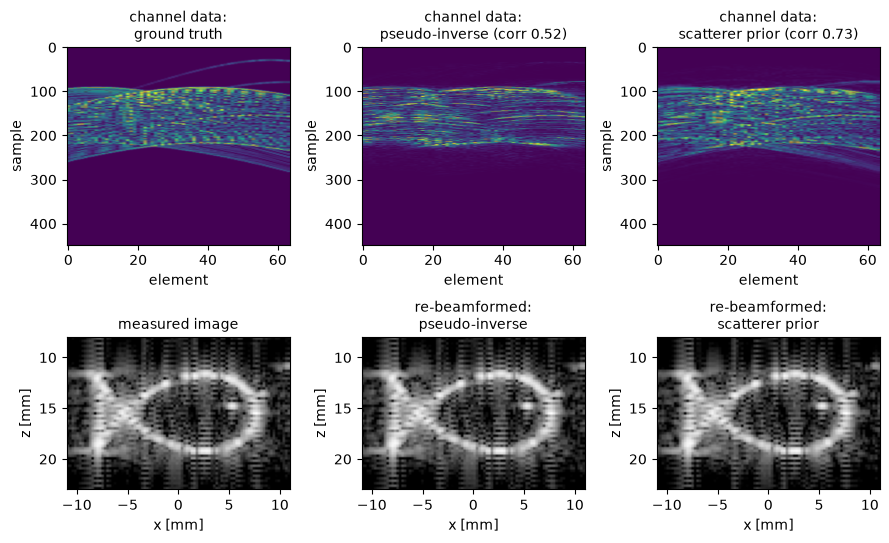

In [7]:
tx = 1  # center (zero-angle) transmit
panels = [
    (channel_data_true, "ground truth"),
    (result_direct.channel_data, "pseudo-inverse"),
    (result_scat.channel_data, "scatterer prior"),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for ax, (cube, title) in zip(axes[0], panels):
    cube = np.asarray(ops.convert_to_numpy(cube))
    label = "" if title == "ground truth" else f" (corr {correlation(cube, channel_data_true):.2f})"
    ax.imshow(
        np.abs(cube[tx]), aspect="auto", cmap="viridis", vmax=np.percentile(np.abs(cube[tx]), 99.5)
    )
    ax.set_title(f"channel data:\n{title}{label}", fontsize=10)
    ax.set(xlabel="element", ylabel="sample")

images = [(image_measured, "measured image")] + [
    (result.image, f"re-beamformed:\n{title}")
    for result, (_, title) in zip([result_direct, result_scat], panels[1:])
]
for ax, (flat, title) in zip(axes[1], images):
    ax.imshow(to_bmode(flat), cmap="gray", vmin=-40, vmax=0, extent=extent, aspect="equal")
    ax.set_title(title, fontsize=10)
    ax.set(xlabel="x [mm]", ylabel="z [mm]")
plt.tight_layout()
plt.show()

## Takeaways

- Both inversions **fit the image** nearly perfectly — the post-beamformed image barely
  constrains which channel data produced it.
- Only the **scatterer prior** recovers the physical channel data (the hyperbolic echo
  signatures in the top row): its parameterization regularizes the ~`n_el * n_tx`-fold
  nullspace of the DAS operator.
- Everything here is backend-agnostic Keras: the same code runs on JAX, TensorFlow and PyTorch.
  See the [`zea.inverse` API reference](../../_autosummary/zea.inverse.rst) for the full
  documentation, including joint position refinement (`refine_iters`) with
  [`zea.backend.optimizer.adam`](../../_autosummary/zea.backend.optimizer.rst).
